# lesson 3：Prompt Engineering

- For pretrained models, a prompt is a portal
- For instruction-tuned models, a prompt is a wish
- For agent simulation, a prompt creates a golem

在使用模型时，我们应该给模型提供一种情境，比如：
> A Frech phrase is provided: {source_phrase} \
> The masterful French translator flawlessly \
> translates the phrase to English:

# Lesson 4：Augmented Language Models



**What (base) LLMs are good at**
- Language understanding
- Instruction following
- Basic reasoning
- Code understanding

**What they need help with**
- Up-to-date knowledge
- Knowledge of your data
- More challenging reasoning
- Interacting with the world


## 近年来主要大模型的Context Window

Context Window 是模型一次能处理的最大 token 数量（包含输入 + 输出）。下表梳理了从 GPT-3 至今主流模型的 context window 演进。

### OpenAI 系列

| 模型 | 发布时间 | Context Window |
|------|----------|---------------|
| GPT-3 | 2020.05 | 2,048 tokens |
| GPT-3.5-turbo | 2022.11 | 4,096 tokens |
| GPT-3.5-turbo-16k | 2023.06 | 16,384 tokens |
| GPT-4 | 2023.03 | 8,192 tokens |
| GPT-4-32k | 2023.03 | 32,768 tokens |
| GPT-4 Turbo | 2023.11 | 128,000 tokens |
| GPT-4o | 2024.05 | 128,000 tokens |
| o1 | 2024.09 | 200,000 tokens |
| GPT-4.5 | 2025.02 | 128,000 tokens |
| GPT-4.1 / 4.1-mini / 4.1-nano | 2025.04 | 1,047,576 tokens |
| o3 | 2025.04 | 200,000 tokens |
| o4-mini | 2025.04 | 200,000 tokens |
| GPT-5 | 2025.08 | 400,000 tokens（API） |
| GPT-5.2 | 2025.12 | 400,000 tokens |
| GPT-5.4 | 2026.03 | 1,000,000 tokens |

#### 为什么 GPT-5 的 context window 反而比 GPT-4.1 小？

GPT-5 初版（400K）比 GPT-4.1（1M）更小，背后有几个原因：

**1. 推理 token 消耗 context 额度**

GPT-5 是混合推理模型，内部会生成大量不可见的"thinking tokens"完成思维链推理，这些 token 全部计入 context window 总额度。对推理模型来说，1M context 意味着大量计算成本被内部推理消耗，留给用户内容的空间被大幅压缩。

**2. 推理能力本身可以替代大 context**

Zep 的实测数据说明问题：o4-mini（200K context）在长文档记忆任务上准确率 **72.78%**，反而高于 GPT-4.1（1M context）的 **56.72%**。更强的推理能力让模型更善于从有限输入中提取关键信息，而不是靠暴力堆入所有内容。

**3. "有效 context"远小于宣传值——Context Rot 问题**

- **Lost in the Middle**（TACL 2024）：关键信息在上下文中间时性能显著下降，准确率呈 U 形曲线
- **Context Rot**（Chroma 2025）：随着输入变长，模型性能越来越不稳定；实测发现模型的"有效上下文"比宣传值低 **99%**；GPT-4o 准确率从 99% 降至 70%，Claude 3.5 Sonnet 从 88% 降至 30%

**4. O(n²) 的计算代价**

Transformer 注意力机制是平方复杂度，context 翻倍计算量翻四倍。推理模型每步思考消耗大量 token，与超长 context 叠加后成本极高——GPT-5.4 中超过 272K token 的请求需要按 **2× 费率**计费，直接体现了这个代价。

> **结论**：2025 年之后，context window 军备竞赛让位于推理能力竞赛。大 context 是必要条件但不是核心竞争力，ROI 越来越低；推理深度才是模型之间真正拉开差距的变量。GPT-5.4 最终也补回了 1M，说明这不是技术瓶颈，而是早期版本在质量和规模之间的优先级取舍。

### Anthropic Claude 系列

| 模型 | 发布时间 | Context Window |
|------|----------|---------------|
| Claude 1 | 2023.03 | 9,000 tokens |
| Claude 2 | 2023.07 | 100,000 tokens |
| Claude 3（Haiku / Sonnet / Opus） | 2024.03 | 200,000 tokens |
| Claude 3.5 Sonnet / Haiku | 2024.10 | 200,000 tokens |
| Claude 3.7 Sonnet | 2025.02 | 200,000 tokens |
| Claude 4 Sonnet / Opus | 2025.05 | 200,000 tokens（初版）|
| Claude 4 Haiku (Haiku 4.5) | 2025 | 200,000 tokens |
| Claude 4 Sonnet (Sonnet 4.6) | 2026.02 | 1,000,000 tokens |
| Claude 4 Opus (Opus 4.6) | 2026.02 | 1,000,000 tokens |

> Claude Opus 4.6 / Sonnet 4.6 在 2026 年迭代后将 context window 升至 1M tokens。

### Google Gemini 系列

| 模型 | 发布时间 | Context Window |
|------|----------|---------------|
| Gemini 1.0 Pro | 2023.12 | 32,768 tokens |
| Gemini 1.5 Pro | 2024.05 | 1,000,000 tokens（最高 2M）|
| Gemini 2.0 Flash | 2025.02 | 1,048,576 tokens |
| Gemini 2.5 Pro | 2025.03 | 1,048,576 tokens |
| Gemini 3 Pro | 2025.11 | 1,000,000 tokens |

### Meta Llama 系列（开源）

| 模型 | 发布时间 | Context Window |
|------|----------|---------------|
| Llama 2 | 2023.07 | 4,096 tokens |
| Llama 3 | 2024.04 | 8,192 tokens |
| Llama 3.1 | 2024.07 | 128,000 tokens |
| Llama 3.3 | 2024.12 | 128,000 tokens |
| Llama 4 Maverick（MoE，400B） | 2025.04 | 1,000,000 tokens |
| Llama 4 Scout（MoE，109B） | 2025.04 | 10,000,000 tokens |

> Llama 4 Scout 的 10M context window 是目前开源模型中最大的，原生支持多模态（文本 + 图像）。

### DeepSeek 系列（国产开源）

| 模型 | 发布时间 | Context Window |
|------|----------|---------------|
| DeepSeek V2 | 2024.05 | 128,000 tokens |
| DeepSeek V3 | 2024.12 | 128,000 tokens |
| DeepSeek R1 | 2025.01 | 128,000 tokens |
| DeepSeek V3-0324 | 2025.03 | 128,000 tokens |
| DeepSeek R1-0528 | 2025.05 | 128,000 tokens |
| DeepSeek V3.1 | 2025.08 | 128,000 tokens |
| DeepSeek V3.2 | 2025.12 | 128,000 tokens |

> DeepSeek 系列 context window 维持 128K，通过模型架构和推理能力的持续优化保持竞争力。

### 关键趋势

- **2020–2022**：主流 context window 在 2K–4K tokens，LLM 主要用于短文本任务
- **2023**：出现 100K 级别突破（Claude 2），长文档处理成为可能
- **2024**：128K 成为新基准（GPT-4 Turbo、Llama 3.1），Gemini 1.5 Pro 将上限推至 1M
- **2025 上半年**：GPT-4.1、Llama 4 Maverick 实现 1M，Llama 4 Scout 突破 10M
- **2025 下半年–2026**：竞争重心转向推理能力，GPT-5 系列逐步从 400K 升至 1M，Claude Opus/Sonnet 4.6 达到 1M

> **注意**：更大的 context window ≠ 更好的实际效果。模型在超长上下文中对中间部分的注意力会下降（"lost in the middle" 问题），RAG 等增强技术仍有其价值。

## Augmented Language Models

- Retrieval：用外部知识源，在回答时动态补充信息，增强模型的知识覆盖、事实性和上下文能力
- Chains：把一个复杂任务拆成多个步骤，通过多轮 LLM 调用串联起来，让整体效果优于一次性直接回答
- Tools：让 LLM 不只是“说”，还能“调用外部系统去做事”或“获取精确结果”


## Embeddings to know

- The OG: Word2Vec
- The baseline: Sentence transformers
- A multimodal option: CLIP
- The one to use: OpenAl
- Where things are going: Instructor


## 三种"Embedding"的区别

"Embedding"这个词在 LLM 语境里至少指三件不同的事，混在一起很容易让人困惑。

---

### 1. Token Embedding（输入嵌入）

**发生时机**：模型接收输入的第一步。

文本先被分词器（tokenizer）切成 token，每个 token 是一个整数 ID。模型内部有一张**嵌入矩阵**（Embedding Matrix），形状为 `[词表大小 × 隐藏维度]`，例如 GPT-3（175B）是 `[50257 × 12288]`。每个 token ID 在这张表里查一行，就得到该 token 的初始向量。

**关键特点**：
- 每次查到的向量**完全一样**，与上下文无关
- "bank"无论出现在"river bank"还是"bank account"里，查到的初始向量相同
- 这张矩阵是训练出来的参数，是模型权重的一部分

```
"Hello world" 
  → tokenizer → [15496, 995]
  → 查嵌入矩阵 → [向量A, 向量B]   # 每个向量 12288 维（GPT-3 为例）
```

> 不同模型的隐藏维度不同，例如 GPT-2 small 为 768，Llama 3 8B 为 4096，GPT-3 175B 为 12288。

#### 训练阶段 vs 推理阶段

**训练阶段**：嵌入矩阵从随机初始化开始（通常是均值为 0 的小随机数），和模型所有其他参数一起，通过反向传播不断更新。训练结束后，每个 token 的向量已编码了真实的语义关系——语义相近的 token 向量更接近，无关的更远。这就是 Word2Vec 发现的规律 `king - man + woman ≈ queen` 的来源。

**推理阶段**：嵌入矩阵已固定，作为模型权重的一部分保存在权重文件里。推理时只做只读查表，同一个 token 每次得到的向量完全相同，没有任何随机性。

> 推理时输出的随机性（temperature > 0）来自**最后一步对概率分布的采样**，与 embedding 查表无关。

**嵌入矩阵是模型参数的一部分**，训练结束后保存在权重文件中：

```
模型权重文件
├── Embedding Matrix       [50257 × 12288]   ← token → 初始向量的查找表（训练所得）
├── Transformer Layer 1
│   ├── Attention (Q/K/V/O 矩阵)
│   └── FFN 权重
├── Transformer Layer 2~N  （GPT-3 共 96 层）
│   └── ...
└── Output LM Head         [12288 × 50257]   ← 将最终 hidden state 映射回词表概率
```

> GPT 系列通常让 Embedding Matrix 和 Output LM Head **共享同一组权重**（weight tying）——输入查表和输出预测用的是同一张矩阵，方向相反。这样既减少参数量，也保证输入和输出语义的一致性。

---

### 2. Hidden States（隐藏状态 / 上下文表示）

**发生时机**：token embedding 进入 Transformer 各层之后。

每一层的 Self-Attention 让每个 token 的向量都能"看到"序列中所有其他 token，逐层更新。经过 N 层之后，每个 token 的向量已经**融入了整个上下文的语义**。

**关键特点**：
- 同一个词在不同语境中得到**不同的向量**（"bank"在河边 vs 银行语境下向量不同）
- 最后一层的 hidden state 就是模型用来预测下一个 token 的"理解结果"
- 这就是为什么 Transformer 比 Word2Vec 强大：后者的向量是静态的，前者是动态的

```
[向量A, 向量B]   # 维度不变，仍是 12288
  → Transformer Layer 1（Self-Attention + FFN）
  → Transformer Layer 2
  → ...
  → Transformer Layer N（GPT-3 共 96 层）
  → [上下文感知的向量A', 上下文感知的向量B']   # 维度仍是 12288，但内容已融入全局语义
```

---

### 3. Sentence / Document Embedding（语义嵌入，用于检索）

**发生时机**：在专门的 Embedding 模型中，对整段文本输出**一个**向量。

这类模型（如 `text-embedding-3-small`、`text-embedding-ada-002`）通常基于 Transformer，但训练目标不同——它们被专门优化为：**语义相近的文本，向量距离近；语义不同的文本，向量距离远**。常用方式是对最后一层所有 token 的 hidden state 做平均池化（mean pooling）或取 `[CLS]` token 向量，压缩成一个固定维度的向量（如 1536 维）。

**关键特点**：
- 整段文本 → 一个向量（不管文本多长）
- 用于**语义搜索、RAG 检索、相似度计算**
- 这个向量本身不能直接用来生成文本，它只是一个"语义坐标"

```
"如何申请信用卡？"  →  embedding 模型  →  [0.12, -0.34, ..., 0.87]  # 1536 维向量
"信用卡办理流程"    →  embedding 模型  →  [0.11, -0.33, ..., 0.85]  # 两者向量很近
"今天天气怎么样？"  →  embedding 模型  →  [-0.9, 0.21, ..., -0.44]  # 与上面距离很远
```

---

### 三者对比总结

| | Token Embedding | Hidden States | Sentence Embedding |
|---|---|---|---|
| **输出粒度** | 每个 token 一个向量 | 每个 token 一个向量 | 整段文本一个向量 |
| **是否含上下文** | 否（静态查表） | 是（动态更新） | 是（压缩后的全局语义）|
| **用途** | 模型内部输入层 | 模型内部推理 | 语义搜索 / RAG |
| **典型维度** | 与模型隐藏维度一致 | 与模型隐藏维度一致 | 768 / 1536 / 3072 |
| **能否生成文本** | 配合完整模型可以 | 配合完整模型可以 | 不能，仅用于检索 |

---

### 在 RAG 中的实际流程

```
【建库阶段】
文档 → Sentence Embedding 模型 → 向量 → 存入向量数据库（Chroma / Pinecone / Faiss）

【检索阶段】
用户问题 → Sentence Embedding 模型 → 查询向量 → 向量数据库相似度搜索 → Top-K 相关文档

【生成阶段】
Top-K 文档 + 用户问题 → 拼接成 Prompt → LLM（内部用 Token Embedding + Hidden States）→ 回答
```

> RAG 里用的 Embedding 是**第 3 种**（Sentence Embedding），负责检索；LLM 生成答案时走的是**第 1 + 2 种**（Token Embedding → Hidden States），负责理解和生成。两者是不同模型、不同目的，只在 Prompt 拼接这一步"交汇"。

## ask-fsdl 系统架构

askFSDL 是一个部署在 Modal 无服务器平台上的 RAG 问答系统，通过 Discord Bot 对外提供服务。整个系统由两个独立的 Modal App 构成：

- **askfsdl-backend**（`app.py`）：核心 RAG 服务，负责向量检索 + GPT-4 问答
- **askfsdl-discord**（`bot.py`）：Discord Bot，负责接收用户指令并异步调用后端

下面用两张图分别描述**组件通信关系**和**启动初始化流程**。

/var/folders/k0/nlqc7vt13wd24wjjxks8w4f40000gn/T/ipykernel_90982/118115223.py:156: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/bytedance/miniforge3/envs/llm-eng/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


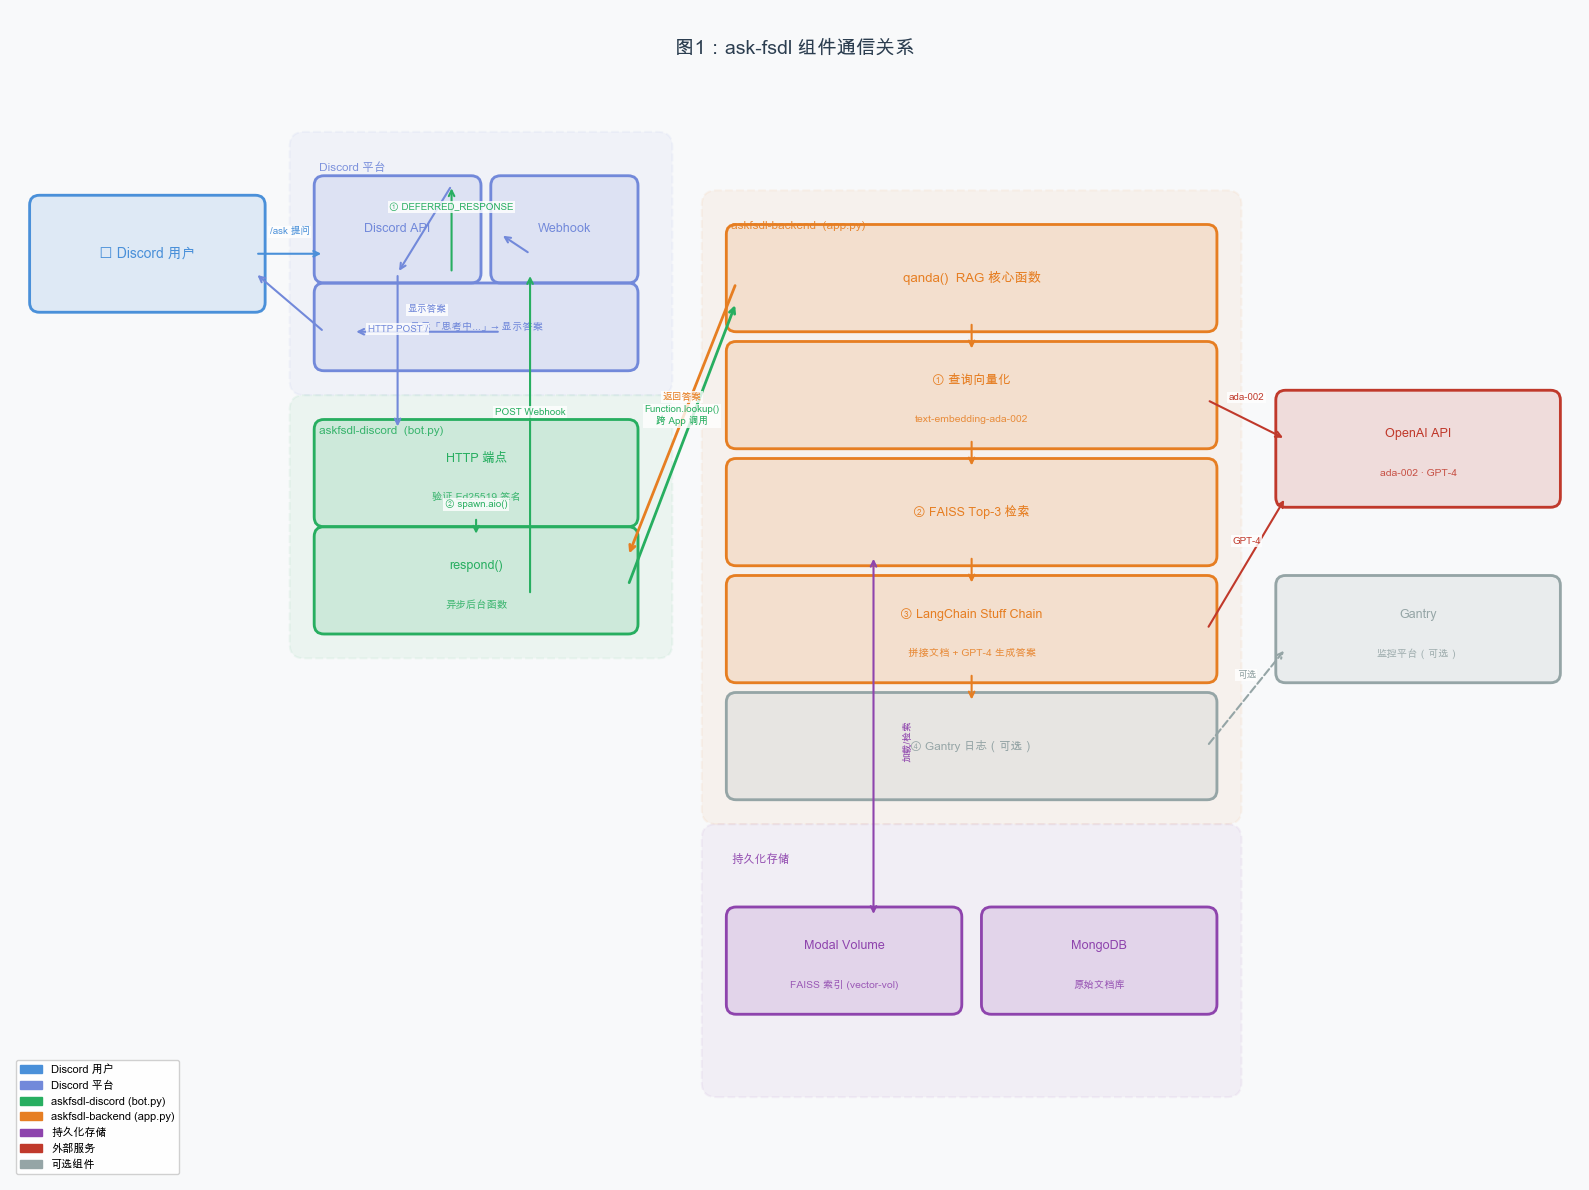

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

# ── 颜色方案 ──────────────────────────────────────────────
C_USER     = '#4A90D9'   # 蓝：用户
C_DISCORD  = '#7289DA'   # 紫：Discord 平台
C_FRONT    = '#27AE60'   # 绿：前端 bot.py
C_BACK     = '#E67E22'   # 橙：后端 app.py
C_STORAGE  = '#8E44AD'   # 紫红：存储
C_EXTERNAL = '#C0392B'   # 红：外部服务
C_OPTIONAL = '#95A5A6'   # 灰：可选

def box(ax, x, y, w, h, label, color, fontsize=9, alpha=0.15, sublabel=''):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor=color,
                          alpha=alpha, linewidth=2, zorder=2)
    ax.add_patch(rect)
    rect2 = FancyBboxPatch((x, y), w, h,
                           boxstyle="round,pad=0.1",
                           fill=False, edgecolor=color,
                           linewidth=2, zorder=3)
    ax.add_patch(rect2)
    cy = y + h / 2 + (0.15 if sublabel else 0)
    ax.text(x + w/2, cy, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=color, zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85, zorder=4)

def group_box(ax, x, y, w, h, title, color):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.15",
                          facecolor=color, edgecolor=color,
                          alpha=0.06, linewidth=1.5,
                          linestyle='--', zorder=1)
    ax.add_patch(rect)
    ax.text(x + 0.15, y + h - 0.25, title, fontsize=8.5,
            color=color, fontweight='bold', alpha=0.9, zorder=4)

def arrow(ax, x1, y1, x2, y2, label='', color='#555', lw=1.5, style='->', linestyle='-'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color,
                                lw=lw, linestyle=linestyle,
                                connectionstyle='arc3,rad=0.0'),
                zorder=5)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.18, label, ha='center', va='bottom',
                fontsize=7, color=color, zorder=6,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# ── 标题 ──────────────────────────────────────────────────
ax.text(8, 11.6, '图1：ask-fsdl 组件通信关系', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2C3E50')

# ── 用户 ──────────────────────────────────────────────────
box(ax, 0.3, 9.0, 2.2, 1.0, '👤 Discord 用户', C_USER, fontsize=10)

# ── Discord 平台 ──────────────────────────────────────────
group_box(ax, 3.0, 8.2, 3.6, 2.4, 'Discord 平台', C_DISCORD)
box(ax, 3.2, 9.3, 1.5, 0.9, 'Discord API', C_DISCORD)
box(ax, 5.0, 9.3, 1.3, 0.9, 'Webhook', C_DISCORD)
box(ax, 3.2, 8.4, 3.1, 0.7, '显示「思考中...」→ 显示答案', C_DISCORD, fontsize=7.5)

# ── 前端 bot.py ───────────────────────────────────────────
group_box(ax, 3.0, 5.5, 3.6, 2.4, 'askfsdl-discord  (bot.py)', C_FRONT)
box(ax, 3.2, 6.8, 3.1, 0.9, 'HTTP 端点', C_FRONT, sublabel='验证 Ed25519 签名')
box(ax, 3.2, 5.7, 3.1, 0.9, 'respond()', C_FRONT, sublabel='异步后台函数')

# ── 后端 app.py ───────────────────────────────────────────
group_box(ax, 7.2, 3.8, 5.2, 6.2, 'askfsdl-backend  (app.py)', C_BACK)
box(ax, 7.4, 8.8, 4.8, 0.9, 'qanda()  RAG 核心函数', C_BACK, fontsize=9.5)
box(ax, 7.4, 7.6, 4.8, 0.9, '① 查询向量化', C_BACK, sublabel='text-embedding-ada-002')
box(ax, 7.4, 6.4, 4.8, 0.9, '② FAISS Top-3 检索', C_BACK)
box(ax, 7.4, 5.2, 4.8, 0.9, '③ LangChain Stuff Chain', C_BACK, sublabel='拼接文档 + GPT-4 生成答案')
box(ax, 7.4, 4.0, 4.8, 0.9, '④ Gantry 日志（可选）', C_OPTIONAL, fontsize=8.5)

# ── 存储 ──────────────────────────────────────────────────
group_box(ax, 7.2, 1.0, 5.2, 2.5, '持久化存储', C_STORAGE)
box(ax, 7.4, 1.8, 2.2, 0.9, 'Modal Volume', C_STORAGE, sublabel='FAISS 索引 (vector-vol)')
box(ax, 10.0, 1.8, 2.2, 0.9, 'MongoDB', C_STORAGE, sublabel='原始文档库')

# ── 外部服务 ──────────────────────────────────────────────
box(ax, 13.0, 7.0, 2.7, 1.0, 'OpenAI API', C_EXTERNAL, sublabel='ada-002 · GPT-4')
box(ax, 13.0, 5.2, 2.7, 0.9, 'Gantry', C_OPTIONAL, fontsize=9, sublabel='监控平台（可选）')

# ── 箭头：用户 ↔ Discord ─────────────────────────────────
arrow(ax, 2.5, 9.5, 3.2, 9.5, '/ask 提问', C_USER)
arrow(ax, 5.0, 8.7, 3.5, 8.7, '显示答案', C_DISCORD)

# ── 箭头：Discord API → bot HTTP ─────────────────────────
arrow(ax, 3.95, 9.3, 3.95, 7.7, 'HTTP POST /', C_DISCORD)

# ── 箭头：bot HTTP 立即 DEFER 返回 ─────────────────────────
arrow(ax, 4.5, 9.3, 4.5, 10.2, '① DEFERRED_RESPONSE', C_FRONT)
ax.annotate('', xy=(3.95, 9.3), xytext=(4.5, 10.2),
            arrowprops=dict(arrowstyle='->', color=C_DISCORD, lw=1.5),
            zorder=5)

# ── 箭头：bot HTTP → respond() ────────────────────────────
arrow(ax, 4.75, 6.8, 4.75, 6.6, '② spawn.aio()', C_FRONT)

# ── 箭头：respond() → qanda() ────────────────────────────
arrow(ax, 6.3, 6.1, 7.4, 9.0, 'Function.lookup()\n跨 App 调用', C_FRONT, lw=2)

# ── 箭头：app 内部流程 ─────────────────────────────────────
arrow(ax, 9.8, 8.8, 9.8, 8.5, '', C_BACK)
arrow(ax, 9.8, 7.6, 9.8, 7.3, '', C_BACK)
arrow(ax, 9.8, 6.4, 9.8, 6.1, '', C_BACK)
arrow(ax, 9.8, 5.2, 9.8, 4.9, '', C_BACK)

# ── 箭头：向量化 → OpenAI ────────────────────────────────
arrow(ax, 12.2, 8.0, 13.0, 7.6, 'ada-002', C_EXTERNAL)

# ── 箭头：FAISS ↔ Volume ─────────────────────────────────
ax.annotate('', xy=(8.8, 2.7), xytext=(8.8, 6.4),
            arrowprops=dict(arrowstyle='<->', color=C_STORAGE, lw=1.5), zorder=5)
ax.text(9.1, 4.5, '加载/检索', fontsize=7, color=C_STORAGE,
        rotation=90, va='center', zorder=6)

# ── 箭头：LangChain → OpenAI ─────────────────────────────
arrow(ax, 12.2, 5.65, 13.0, 7.0, 'GPT-4', C_EXTERNAL)

# ── 箭头：④ Gantry ────────────────────────────────────────
arrow(ax, 12.2, 4.45, 13.0, 5.45, '可选', C_OPTIONAL, linestyle='--')

# ── 箭头：答案返回 respond() ─────────────────────────────
arrow(ax, 7.4, 9.2, 6.3, 6.4, '返回答案', C_BACK, lw=2)

# ── 箭头：respond() → Webhook → 用户 ────────────────────
arrow(ax, 5.3, 6.0, 5.3, 9.3, 'POST Webhook', C_FRONT)
arrow(ax, 5.3, 9.5, 5.0, 9.7, '', C_DISCORD)
arrow(ax, 3.2, 8.7, 2.5, 9.3, '', C_DISCORD)

# ── 图例 ─────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_USER,     label='Discord 用户'),
    mpatches.Patch(color=C_DISCORD,  label='Discord 平台'),
    mpatches.Patch(color=C_FRONT,    label='askfsdl-discord (bot.py)'),
    mpatches.Patch(color=C_BACK,     label='askfsdl-backend (app.py)'),
    mpatches.Patch(color=C_STORAGE,  label='持久化存储'),
    mpatches.Patch(color=C_EXTERNAL, label='外部服务'),
    mpatches.Patch(color=C_OPTIONAL, label='可选组件'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8,
          framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.show()

/var/folders/k0/nlqc7vt13wd24wjjxks8w4f40000gn/T/ipykernel_90982/2424677162.py:147: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/Users/bytedance/miniforge3/envs/llm-eng/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial Unicode MS.
  fig.canvas.print_figure(bytes_io, **kw)


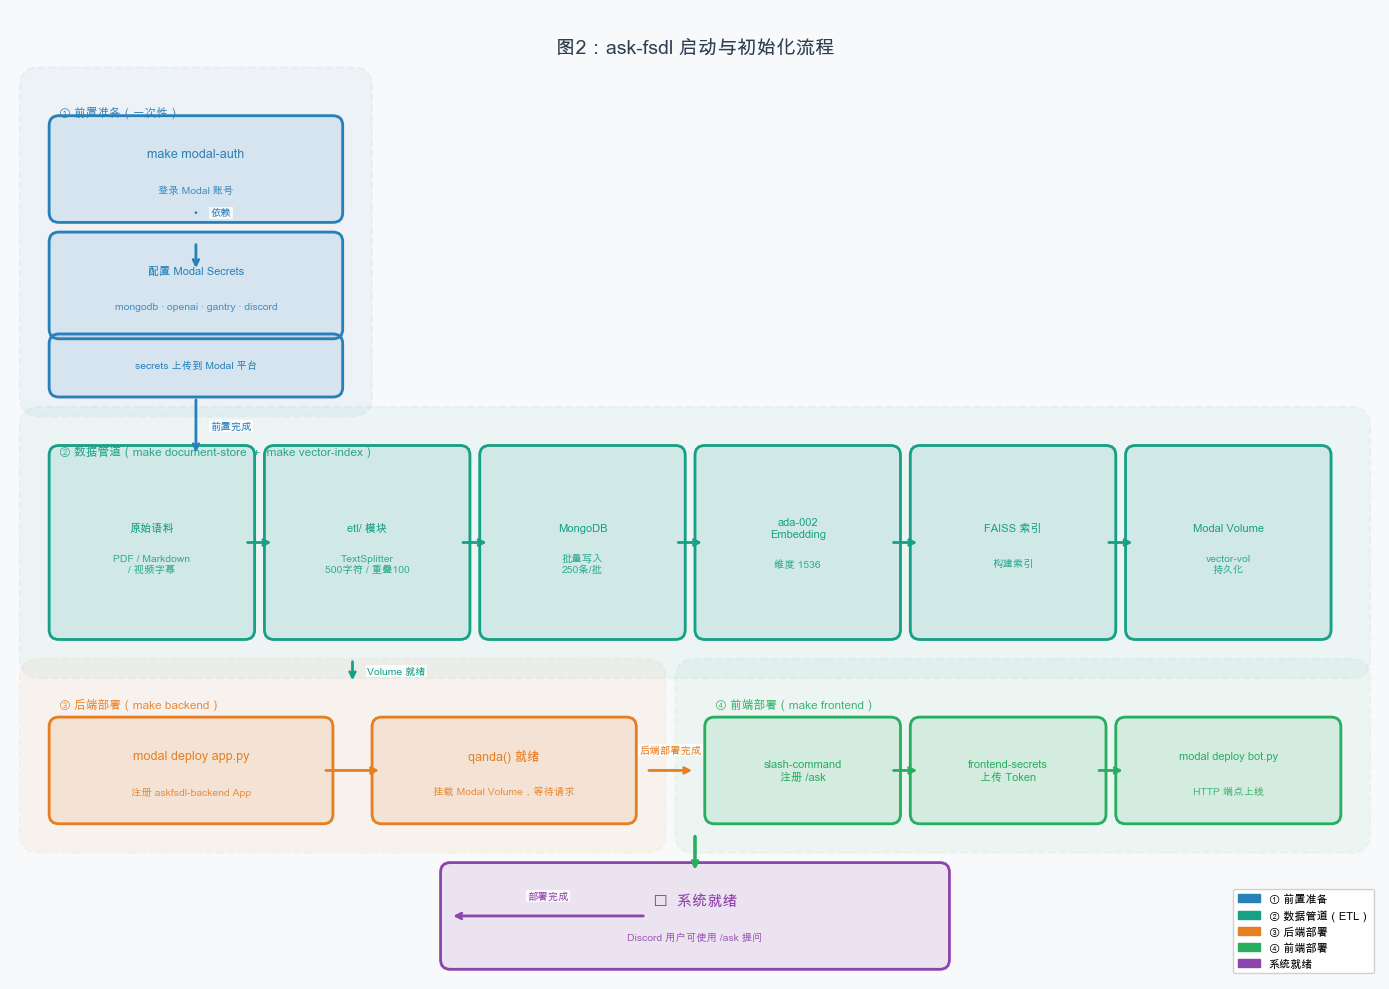

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

C_PRE      = '#2980B9'
C_ETL      = '#16A085'
C_BACKEND  = '#E67E22'
C_FRONTEND = '#27AE60'
C_READY    = '#8E44AD'
C_ARROW    = '#555555'

def box(ax, x, y, w, h, title, color, subtitle='', fontsize=9):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor=color,
                          alpha=0.12, linewidth=2, zorder=2)
    ax.add_patch(rect)
    border = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                            fill=False, edgecolor=color, linewidth=2, zorder=3)
    ax.add_patch(border)
    ty = y + h/2 + (0.15 if subtitle else 0)
    ax.text(x + w/2, ty, title, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=color, zorder=4)
    if subtitle:
        ax.text(x + w/2, y + h/2 - 0.22, subtitle, ha='center', va='center',
                fontsize=7.5, color=color, alpha=0.85, zorder=4)

def group_box(ax, x, y, w, h, title, color):
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2",
                          facecolor=color, edgecolor=color,
                          alpha=0.05, linewidth=1.5, linestyle='--', zorder=1)
    ax.add_patch(rect)
    ax.text(x + 0.2, y + h - 0.3, title, fontsize=8.5,
            color=color, fontweight='bold', alpha=0.9, zorder=4)

def arrow_v(ax, x, y1, y2, label='', color=C_ARROW):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2), zorder=5)
    if label:
        ax.text(x + 0.15, (y1+y2)/2, label, fontsize=7.5, color=color,
                va='center', zorder=6,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

def arrow_h(ax, x1, x2, y, label='', color=C_ARROW):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2), zorder=5)
    if label:
        ax.text((x1+x2)/2, y + 0.18, label, fontsize=7.5, color=color,
                ha='center', zorder=6,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

# ── 标题 ─────────────────────────────────────────────────
ax.text(7, 9.6, '图2：ask-fsdl 启动与初始化流程', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2C3E50')

# ══════════════════════════════════════════════════════════
# 第一列：前置准备（左侧纵向）
# ══════════════════════════════════════════════════════════
group_box(ax, 0.3, 6.0, 3.2, 3.2, '① 前置准备（一次性）', C_PRE)
box(ax, 0.5, 7.9, 2.8, 0.9, 'make modal-auth', C_PRE, subtitle='登录 Modal 账号')
box(ax, 0.5, 6.7, 2.8, 0.9, '配置 Modal Secrets', C_PRE,
    subtitle='mongodb · openai · gantry · discord', fontsize=8)
box(ax, 0.5, 6.1, 2.8, 0.45, 'secrets 上传到 Modal 平台', C_PRE, fontsize=7.5)
arrow_v(ax, 1.9, 7.9, 7.6+0.3, '依赖', C_PRE)
arrow_v(ax, 1.9, 7.6, 7.0+0.3, '', C_PRE)

# ══════════════════════════════════════════════════════════
# 中间：数据管道（ETL）横向展开
# ══════════════════════════════════════════════════════════
group_box(ax, 0.3, 3.3, 13.4, 2.4, '② 数据管道（make document-store  +  make vector-index）', C_ETL)

ETL_STEPS = [
    ('原始语料',     'PDF / Markdown\n/ 视频字幕'),
    ('etl/ 模块',    'TextSplitter\n500字符 / 重叠100'),
    ('MongoDB',      '批量写入\n250条/批'),
    ('ada-002\nEmbedding', '维度 1536'),
    ('FAISS 索引',   '构建索引'),
    ('Modal Volume', 'vector-vol\n持久化'),
]
step_w = 1.9
step_gap = 0.3
start_x = 0.5
for i, (title, sub) in enumerate(ETL_STEPS):
    bx = start_x + i * (step_w + step_gap)
    box(ax, bx, 3.6, step_w, 1.8, title, C_ETL, subtitle=sub, fontsize=8)
    if i < len(ETL_STEPS) - 1:
        arrow_h(ax, bx + step_w, bx + step_w + step_gap, 4.5, color=C_ETL)

# ══════════════════════════════════════════════════════════
# 后端部署
# ══════════════════════════════════════════════════════════
group_box(ax, 0.3, 1.5, 6.2, 1.6, '③ 后端部署（make backend）', C_BACKEND)
box(ax, 0.5, 1.7, 2.7, 0.9, 'modal deploy app.py', C_BACKEND,
    subtitle='注册 askfsdl-backend App')
arrow_h(ax, 3.2, 3.8, 2.15, color=C_BACKEND)
box(ax, 3.8, 1.7, 2.5, 0.9, 'qanda() 就绪', C_BACKEND,
    subtitle='挂载 Modal Volume，等待请求')

# ══════════════════════════════════════════════════════════
# 前端部署
# ══════════════════════════════════════════════════════════
group_box(ax, 7.0, 1.5, 6.7, 1.6, '④ 前端部署（make frontend）', C_FRONTEND)
box(ax, 7.2, 1.7, 1.8, 0.9, 'slash-command\n注册 /ask', C_FRONTEND, fontsize=8)
arrow_h(ax, 9.0, 9.3, 2.15, color=C_FRONTEND)
box(ax, 9.3, 1.7, 1.8, 0.9, 'frontend-secrets\n上传 Token', C_FRONTEND, fontsize=8)
arrow_h(ax, 11.1, 11.4, 2.15, color=C_FRONTEND)
box(ax, 11.4, 1.7, 2.1, 0.9, 'modal deploy bot.py', C_FRONTEND,
    subtitle='HTTP 端点上线', fontsize=8)

# ══════════════════════════════════════════════════════════
# 系统就绪
# ══════════════════════════════════════════════════════════
box(ax, 4.5, 0.2, 5.0, 0.9, '✅  系统就绪', C_READY,
    subtitle='Discord 用户可使用 /ask 提问', fontsize=11)

# ── 阶段间箭头 ────────────────────────────────────────────
# 前置 → ETL
arrow_v(ax, 1.9, 6.0, 5.4, '前置完成', C_PRE)
# ETL → 后端
arrow_v(ax, 3.5, 3.3, 2.4+0.65, 'Volume 就绪', C_ETL)
# 后端 → 前端
arrow_h(ax, 6.5, 7.0, 2.15, '后端部署完成', C_BACKEND)
# 前端 → Ready
arrow_v(ax, 7.0, 1.5, 1.1, '', C_FRONTEND)
ax.annotate('', xy=(7.0, 1.1), xytext=(7.0, 1.5),
            arrowprops=dict(arrowstyle='->', color=C_FRONTEND, lw=2), zorder=5)
ax.annotate('', xy=(7.0, 1.1), xytext=(7.0, 1.5),
            arrowprops=dict(arrowstyle='->', color=C_FRONTEND, lw=2), zorder=5)
arrow_h(ax, 6.5, 4.5, 0.65, '部署完成', C_READY)

# ── 图例 ─────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_PRE,      label='① 前置准备'),
    mpatches.Patch(color=C_ETL,      label='② 数据管道（ETL）'),
    mpatches.Patch(color=C_BACKEND,  label='③ 后端部署'),
    mpatches.Patch(color=C_FRONTEND, label='④ 前端部署'),
    mpatches.Patch(color=C_READY,    label='系统就绪'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.show()